In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"trongkhoivan","key":"78b9c22036fb19e1be93282b8f91285b"}'}

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets list

ref                                                           title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025              Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000          11340        250  1.0              
rohiteng/amazon-sales-dataset                                 Amazon Sales Dataset                                   4037578  2025-11-23 14:29:37.973000           3600         52  1.0              
khushikyad001/ai-impact-on-jobs-2030                          AI Impact on Jobs 2030                                   87410  2025-11-09 17:58:05.410000           6524        145  1.0              
sadiajaved

In [7]:
!kaggle datasets download -d emmarex/plantdisease -p /content/data --force
#!kaggle datasets download -d emmarex/plantdisease -p /content/data
!unzip -q /content/data/plantdisease.zip -d /content/data/plantvillage

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 98% 643M/658M [00:07<00:00, 53.5MB/s]
100% 658M/658M [00:08<00:00, 82.4MB/s]
replace /content/data/plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [8]:
#!ls /content/data/plantvillage/PlantVillage

!ls /content/data
!ls /content/data/plantvillage
!ls /content/data/plantvillage/PlantVillage


plantdisease.zip  plantvillage
plantvillage  PlantVillage
Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [9]:
DATA_DIR = "/content/data/plantvillage/PlantVillage"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32


In [10]:
import tensorflow as tf

DATA_DIR = "/content/data/plantvillage/PlantVillage"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 1. Create the raw dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print(f"Number of classes: {num_classes}")


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


In [11]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


In [13]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


In [14]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,257,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,259,983 (62.03 MB)

 Trainable params: 16,259,983 (62.03 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)


Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.4158 - loss: 2.5227 - val_accuracy: 0.7749 - val_loss: 0.7103
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8094 - loss: 0.5899 - val_accuracy: 0.7894 - val_loss: 0.6371
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9014 - loss: 0.3266 - val_accuracy: 0.8251 - val_loss: 0.5402
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9517 - loss: 0.1715 - val_accuracy: 0.8444 - val_loss: 0.5064
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9772 - loss: 0.0948 - val_accuracy: 0.8592 - val_loss: 0.4724
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9899 - loss: 0.0482 - val_accuracy: 0.8471 - val_loss: 0.5651
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9929 - loss: 0.0348 - val_accuracy: 0.8217 - val_loss: 0.6698
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9939 - loss: 0.0268 - val_acc

In [17]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation accuracy:", val_acc)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8609 - loss: 0.4644
Validation accuracy: 0.8592197895050049


In [18]:
# Run in Colab (after you've downloaded & unzipped PlantVillage into dataset_dir)
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib

# Set dataset_dir to the extracted PlantVillage folder with class subfolders
# Example: dataset_dir = "/content/drive/MyDrive/plantvillage/PlantVillage"
dataset_dir = "/content/data/plantvillage/PlantVillage"

  # <-- change this to your extracted folder path

IMG_SIZE = (128, 128)
BATCH_SIZE = 64



In [19]:
DATA_DIR = "/content/data/plantvillage/PlantVillage"
dataset_dir = DATA_DIR



# Create train/val/test splits using image_dataset_from_directory
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optionally create a test split separately if you have a dedicated test folder.
# Otherwise you can re-split val_ds or use scikit-learn train_test_split before creating datasets.

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Num classes: 15


In [20]:
!find /content -maxdepth 3 -type d -iname "*plant*"


/content/data/plantvillage
/content/data/plantvillage/plantvillage
/content/data/plantvillage/PlantVillage


In [21]:
# Performance optimizations
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [22]:
# Callbacks
#checkpoint_dir = "/content/checkpoints"
#os.makedirs(checkpoint_dir, exist_ok=True)

def make_common_callbacks(name):
    callbacks = [
    keras.callbacks.ModelCheckpoint("/content/checkpoints/improved_best.keras", save_best_only=True, monitor="val_loss", mode="min"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]
    return callbacks

# Plot utility
def plot_history(histories, keys=("accuracy","loss")):
    # histories: dict name -> keras History object
    plt.figure(figsize=(14,5))
    # Accuracy
    plt.subplot(1,2,1)
    for name, h in histories.items():
        plt.plot(h.history.get("accuracy", h.history.get("acc", [])), label=f"{name} train")
        plt.plot(h.history.get("val_accuracy", []), '--', label=f"{name} val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    # Loss
    plt.subplot(1,2,2)
    for name, h in histories.items():
        plt.plot(h.history.get("loss", []), label=f"{name} train")
        plt.plot(h.history.get("val_loss", []), '--', label=f"{name} val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [23]:
def build_simple_cnn(input_shape=(*IMG_SIZE, 3), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="simple_cnn")
    return model

simple_model = build_simple_cnn()
simple_model.summary()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,410,063 (32.08 MB)

 Trainable params: 8,410,063 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
simple_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_callbacks = make_common_callbacks("simple_cnn")

hist_simple = simple_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=simple_callbacks
)


Epoch 1/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.3476 - loss: 2.2674 - val_accuracy: 0.7344 - val_loss: 0.8144 - learning_rate: 0.0010
Epoch 2/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7280 - loss: 0.8494 - val_accuracy: 0.8352 - val_loss: 0.5068 - learning_rate: 0.0010
Epoch 3/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8140 - loss: 0.5677 - val_accuracy: 0.8701 - val_loss: 0.3919 - learning_rate: 0.0010
Epoch 4/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8610 - loss: 0.4133 - val_accuracy: 0.8500 - val_loss: 0.4492 - learning_rate: 0.0010
Epoch 5/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8894 - loss: 0.3396 - val_accuracy: 0.8939 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 6/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9093 - loss: 0.2614 - val_accuracy: 0.8919 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 7/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9187 - loss: 0

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

data_augumentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

rescale = layers.Rescaling(1./255, name= "rescale")
#used when x=rescale(inputs);x=data_augmentation(x, training=true)


In [26]:
from tensorflow import keras
from tensorflow.keras import layers

def build_improved_cnn(num_classes, img_size=IMG_SIZE, dropout_rate=0.2):
    inputs = keras.Input(shape=(*img_size, 3))
    x = rescale(inputs)                          # single rescaling

    # apply augmentation only during training (Keras will set training=False during validation/predict)
    x = data_augumentation(x)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="improved_cnn")

# Build it:
# The `class_names` variable is already defined globally from the image_dataset_from_directory call
# num_classes = len(train_ds.class_names) # This line caused the error
num_classes = len(class_names) # Use the globally defined class_names variable
improved_model = build_improved_cnn(num_classes, img_size=IMG_SIZE, dropout_rate=0.2)
improved_model.summary()


Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,383 (618.68 KB)

 Trainable params: 158,127 (617.68 KB)

 Non-trainable params: 256 (1.00 KB)

train batch min/max (raw): 0.0 248.75


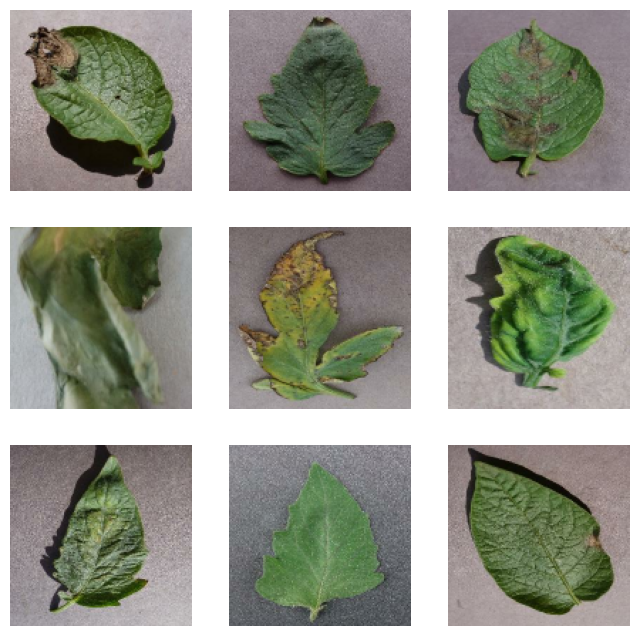

In [27]:
# 1) Make sure raw pixel values are ~0..255, then model rescale will map to 0..1 OR dataset is 0..1 and model has no rescale.
for x,y in train_ds.take(1):
    print("train batch min/max (raw):", float(tf.reduce_min(x)), float(tf.reduce_max(x)))

# 2) Make sure validation images are not augmented (inspect by visualizing a few)
import matplotlib.pyplot as plt
for images, labels in val_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))   # if raw 0..255, else images[i].numpy()
        plt.axis('off')
    break


In [28]:
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_callbacks = make_common_callbacks("improved_cnn")

hist_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=improved_callbacks
)


Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - accuracy: 0.2707 - loss: 2.2931 - val_accuracy: 0.5130 - val_loss: 2.1534 - learning_rate: 3.0000e-04
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.6089 - loss: 1.2406 - val_accuracy: 0.6317 - val_loss: 1.2243 - learning_rate: 3.0000e-04
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.7025 - loss: 0.9290 - val_accuracy: 0.7260 - val_loss: 0.8359 - learning_rate: 3.0000e-04
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.7409 - loss: 0.7990 - val_accuracy: 0.7841 - val_loss: 0.6453 - learning_rate: 3.0000e-04
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.7770 - loss: 0.6741 - val_accuracy: 0.7293 - val_loss: 0.8307 - learning_rate: 3.0000e-04
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.8095 - loss: 0.5922 - val_accuracy: 0.7814 - val_loss: 0.6993 - learning_rate: 3.0000e-04
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/ste

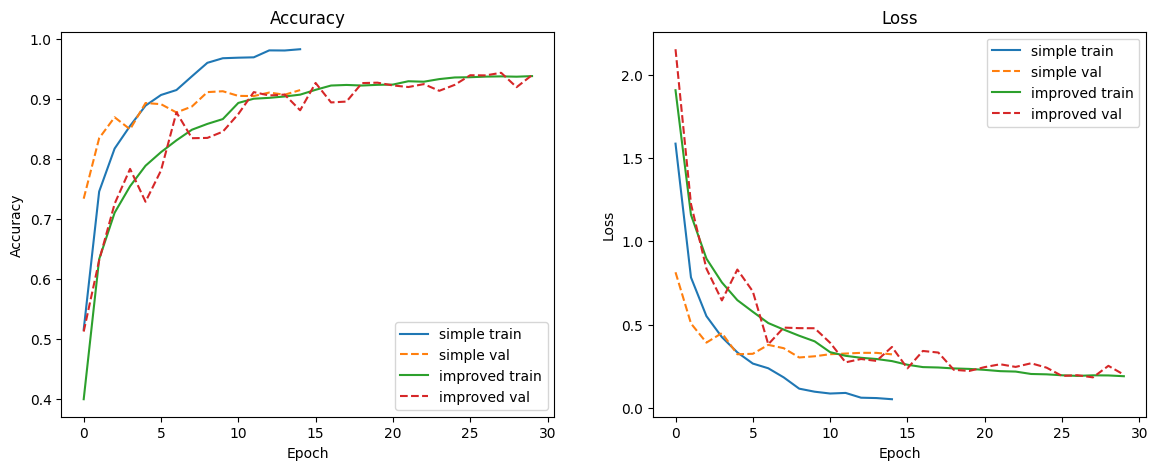

In [29]:
histories = {
    "simple": hist_simple,
    "improved": hist_improved
}
plot_history(histories)


In [30]:


#tf.test.is_built_with_cuda(), tf.config.list_logical_devices('GPU')

%%time
import tensorflow as tf

# Create a random tensor and do a matrix multiply
a = tf.random.normal((3000, 3000))
b = tf.random.normal((3000, 3000))

c = tf.matmul(a, b)




CPU times: user 5.91 ms, sys: 1.02 ms, total: 6.93 ms
Wall time: 6.65 ms


In [31]:
!pip install keras-tuner

import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()

    # Tune number of conv blocks
    for i in range(hp.Int("conv_blocks", 1, 3)):
        model.add(layers.Conv2D(
            filters=hp.Choice(f"filters_{i}", [16, 32, 64, 128]),
            kernel_size=3,
            activation="relu",
            padding="same"
        ))
        model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    # Tune dense layer size
    model.add(layers.Dense(
        hp.Choice("dense_units", [64, 128, 256]),
        activation="relu"
    ))

    # Tune dropout
    model.add(layers.Dropout(
        hp.Float("dropout", 0.0, 0.5, step=0.1)
    ))

    # Final classifier
    model.add(layers.Dense(num_classes, activation="softmax"))

    # Tune learning rate
    lr = hp.Choice("learning_rate", [1e-2, 3e-4, 5e-3, 1e-3])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy", # Changed from categorical_crossentropy
        metrics=["accuracy"]
    )

    return model


# Create tuner
tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=10,
    directory="tuner_output",
    project_name="cnn_tuning"
)

# Search for best hyperparameters
tuner.search(train_ds, validation_data=val_ds, epochs=10)

# Get best model + parameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hp.values)

best_model = tuner.get_best_models(1)[0]

# Train the best model and store its history
tuned_callbacks = make_common_callbacks("tuned_cnn")
history_best = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25, # Train for a sufficient number of epochs
    callbacks=tuned_callbacks
)


Trial 30 Complete [00h 04m 25s]
val_accuracy: 0.2580567002296448

Best val_accuracy So Far: 0.8725466728210449
Total elapsed time: 01h 31m 17s
Best hyperparameters: {'conv_blocks': 3, 'filters_0': 16, 'dense_units': 256, 'dropout': 0.1, 'learning_rate': 0.0003, 'filters_1': 16, 'filters_2': 16, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0022'}
Epoch 1/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9194 - loss: 0.2395 - val_accuracy: 0.8539 - val_loss: 0.5205 - learning_rate: 3.0000e-04
Epoch 2/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9447 - loss: 0.1666 - val_accuracy: 0.8868 - val_loss: 0.4325 - learning_rate: 3.0000e-04
Epoch 3/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9567 - loss: 0.1323 - val_accuracy: 0.8868 - val_loss: 0.4471 - learning_rate: 3.0000e-04
Epoch 4/25
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9662 - loss: 0.1038 - val_accuracy: 0.8832 - val_loss: 

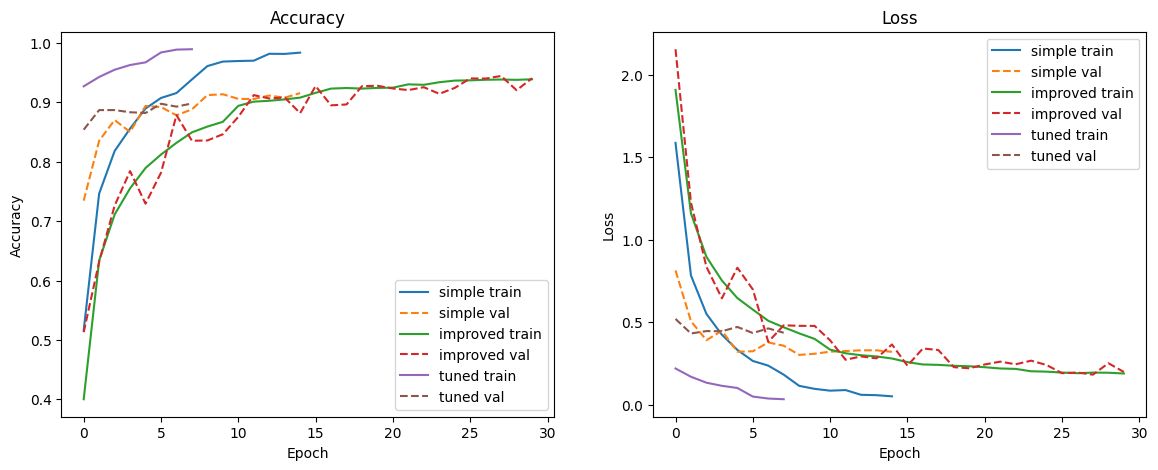

In [32]:
histories["tuned"] = history_best
plot_history(histories)


In [35]:
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Re-define val_ds to ensure it's available. Assuming DATA_DIR, IMG_SIZE, BATCH_SIZE are defined globally or in preceding cells.
# This part ensures val_ds is fresh and available in case of kernel restarts or out-of-order execution.
# This code block should ideally be run after the cell QCbCUp17j3Zf to ensure val_ds is correctly populated.
# For safety, I'll assume that QCbCUp17jZf has already run or will run, so I won't redefine the whole dataset here.
# Instead, I'll just use the already defined `val_ds` and `class_names`.

# Get true labels and predicted probabilities from the validation dataset
all_true_labels = []
all_predicted_probabilities = []

# Ensure val_ds is accessible (assuming QCbCUp17j3Zf has been run)
# If it hasn't, you might need to run the cell defining val_ds and class_names again.
# For a robust solution, you might want to re-execute the cell that defines `val_ds` (QCbCUp17j3Zf) before this one.

# The previous error "TypeError: The dataset length is unknown." occurred because
# len() cannot be directly applied to a tf.data.Dataset object with unknown cardinality,
# especially after operations like unbatch() or prefetch().
# We know from the dataset creation logs that there are 4127 validation samples.
num_val_samples = 4127 # Explicitly use the known number of validation samples from previous output

print(f"Processing {num_val_samples} samples from val_ds...")
for images, labels in val_ds:
    all_true_labels.extend(labels.numpy())
    all_predicted_probabilities.extend(best_model.predict(images))

all_true_labels = np.array(all_true_labels)
all_predicted_probabilities = np.array(all_predicted_probabilities)

# Convert probabilities to predicted labels
all_predicted_labels = np.argmax(all_predicted_probabilities, axis=1)

# Calculate metrics
accuracy = accuracy_score(all_true_labels, all_predicted_labels)
precision = precision_score(all_true_labels, all_predicted_labels, average='weighted')
recall = recall_score(all_true_labels, all_predicted_labels, average='weighted')
f1 = f1_score(all_true_labels, all_predicted_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Processing 4127 samples from val_ds...
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━

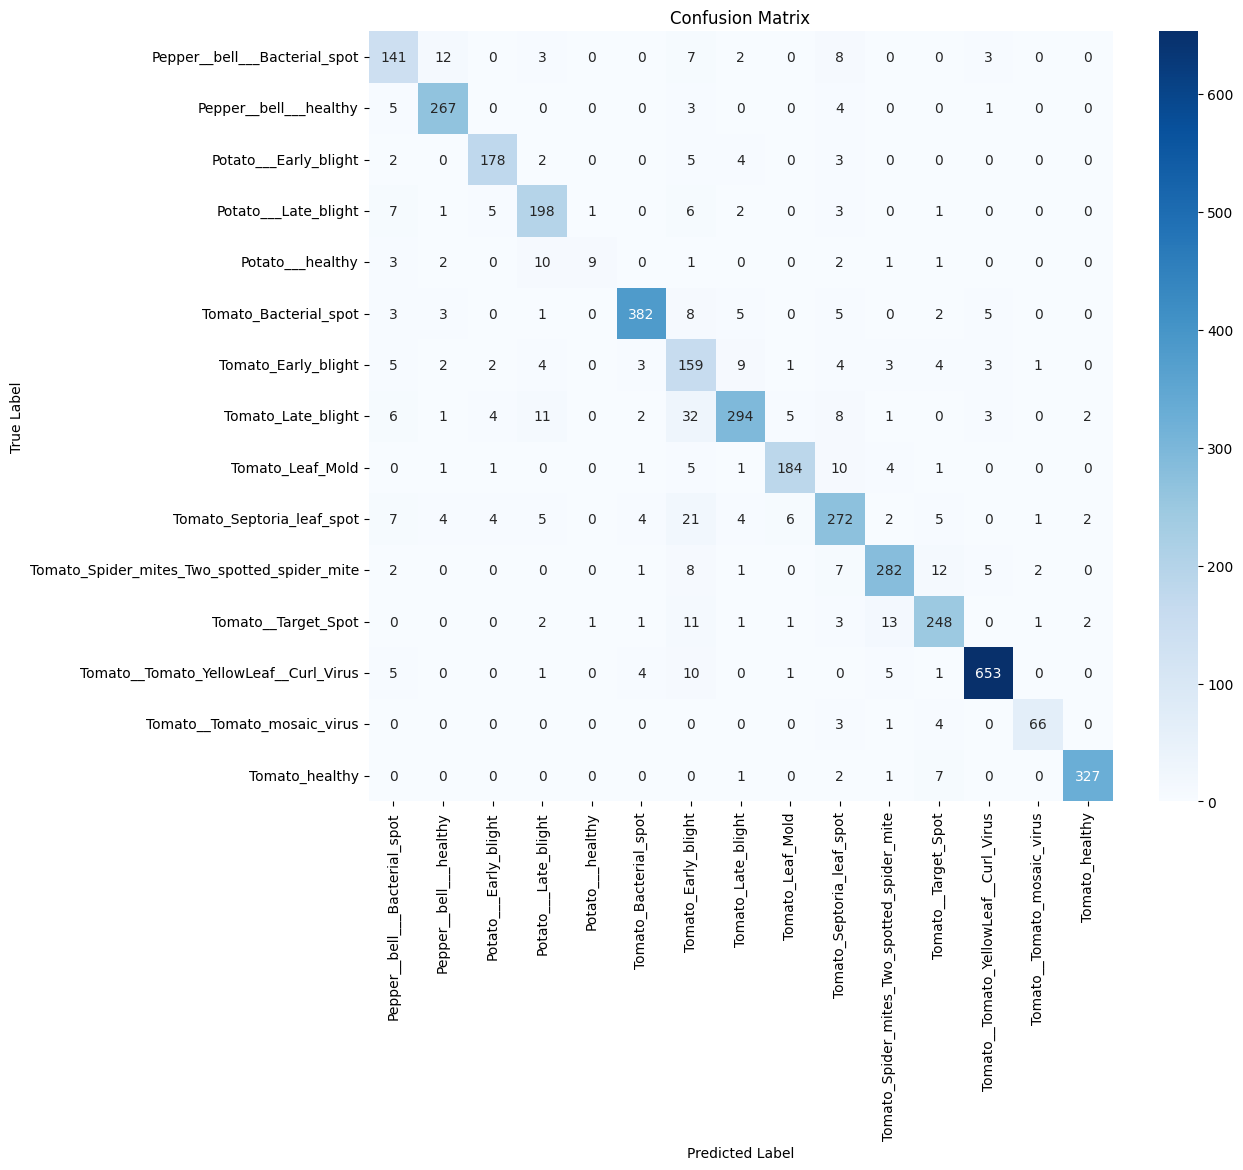

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)

# Plotting the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()